# Task 2 part 1
Here we want to identify which genetic perturbations show similar effects. To do this we cluster the cells individually and assess in which clusters each perturbation is mostly enriched followed by the manual analysis of grouped perturbations in these enriched clusters as well as the computation of purity scores for paper-defined modules. 

In [2]:
# load the filtered RNA data as anndata object
import anndata as ad

data_dir = "/home/ubuntu/data/frangieh"

rna_filtered = ad.read_h5ad(f"{data_dir}/rna_qc_filtered.h5ad")

In [3]:
# Store counts in a separate layer before transforming the data
rna_filtered.layers["counts"] = rna_filtered.X.copy()

In [4]:
# normalize the data to 10000 counts per cell and log-transform the data with a pseudocount of 1
import scanpy as sc
sc.pp.normalize_total(rna_filtered, target_sum = 1e4)
sc.pp.log1p(rna_filtered)

In [5]:
rna_filtered.obs["perturbation_2"].value_counts()

perturbation_2
IFNγ          85100
Co-culture    71143
Control       57627
Name: count, dtype: int64

In [6]:
# split the dataset by perturbation_2 and store the resulting datasets in a dictionary
rna_filtered_split = {
    cond: rna_filtered[rna_filtered.obs["perturbation_2"] == cond].copy()
    for cond in rna_filtered.obs["perturbation_2"].unique()
}

In [7]:
# compute highly variable genes for each split dataset and store them for each split
for key in rna_filtered_split.keys():
    sc.pp.highly_variable_genes(rna_filtered_split[key], n_top_genes = 2000)

In [8]:
# compute PCA for each split dataset (50 dimensions)
for key in rna_filtered_split.keys():
    sc.tl.pca(rna_filtered_split[key])

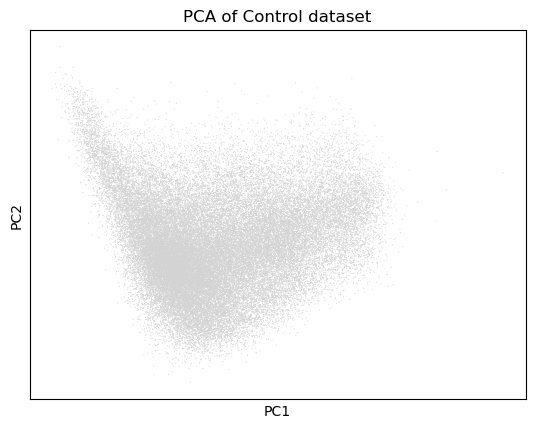

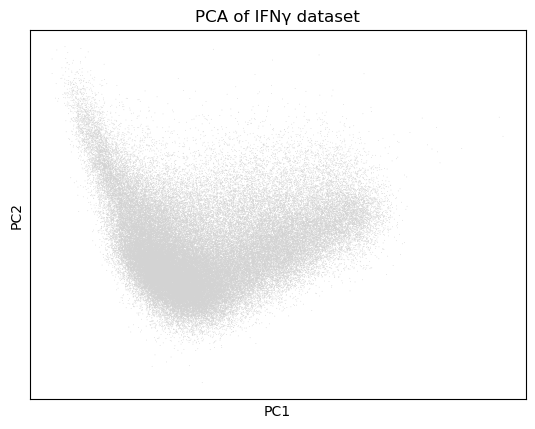

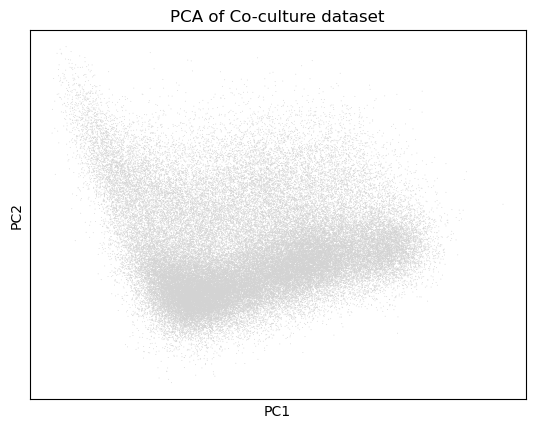

In [9]:
# plot PCA for each split dataset
for key in rna_filtered_split.keys():
    sc.pl.pca(rna_filtered_split[key], dimensions = (0, 1), title = f"PCA of {key} dataset")

In [10]:
# compute neighbors and UMAP for each split from the PCA embeddings
for key in rna_filtered_split.keys():
    sc.pp.neighbors(rna_filtered_split[key])
    sc.tl.umap(rna_filtered_split[key])

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


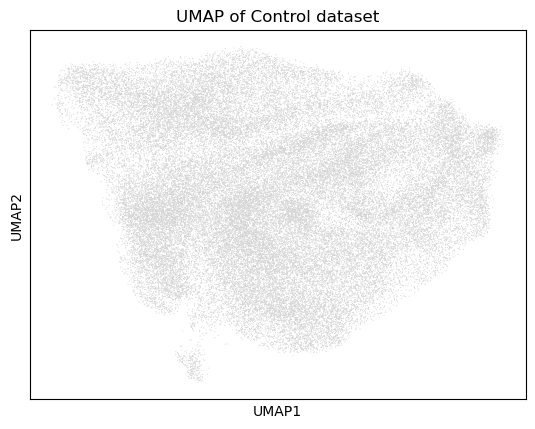

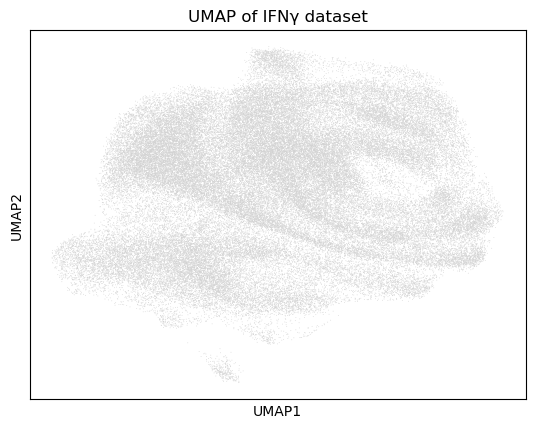

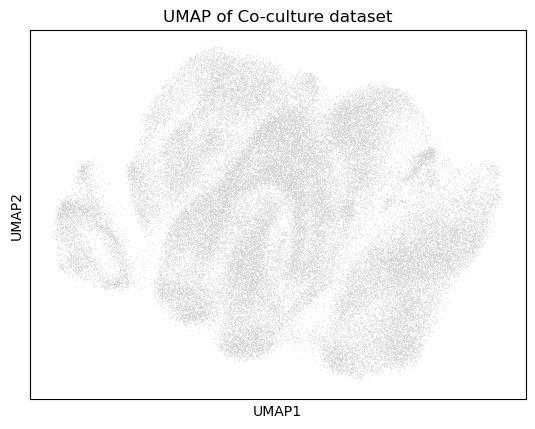

In [11]:
# plot the umaps for each split dataset
for key in rna_filtered_split.keys():
    sc.pl.umap(rna_filtered_split[key], title = f"UMAP of {key} dataset")

In [12]:
# compute leiden clusters with varied resolution using the precompuded neighborhood graphs
for key in rna_filtered_split.keys():
    sc.tl.leiden(rna_filtered_split[key], resolution = 0.5, key_added = "leiden_0.5", flavor = 'igraph', n_iterations = 2, directed = False) # included flavor, n_iterations and directed since it was suggested in the output for faster computation
    sc.tl.leiden(rna_filtered_split[key], resolution = 1.0, key_added = "leiden_1.0", flavor = 'igraph', n_iterations = 2, directed = False)
    sc.tl.leiden(rna_filtered_split[key], resolution = 2.0, key_added = "leiden_2.0", flavor = 'igraph', n_iterations = 2, directed = False)

In [13]:
# compute k means clusters for each split dataset and different k values on the PCA Embeddings
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

kmeans_scores = {}  # create empty dictionary in which data is stored for each split

for key in rna_filtered_split.keys():   # iterate over each split dataset
    X_pca = rna_filtered_split[key].obsm["X_pca"]   # get the PCA embeddings for the current split dataset
    kmeans_scores[key] = {} # initialize a dictionary to store silhouette scores for each k value

    for k in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
        kmeans_labels = KMeans(n_clusters=k, random_state=0, n_init=10).fit_predict(X_pca) # compute k means clustering for the current split dataset and k value with a fixed centroid seed over 10 different starting conditions on the PCA embeddings
        rna_filtered_split[key].obs[f"kmeans_{k}"] = pd.Categorical(kmeans_labels.astype(str)) # build new columns for each k in obs for each split and store the cluster labels as strings and convert them to pandas categorical data type (useed for scanpy and other)
        kmeans_scores[key][k] = silhouette_score(X_pca, kmeans_labels, sample_size=5000, random_state=0) # for each split dataset, compute the silhouette score for each k value and store it in the dictionary

    print(f"{key}: done") # update progress of computation

        


Control: done
IFNγ: done


KeyboardInterrupt: 

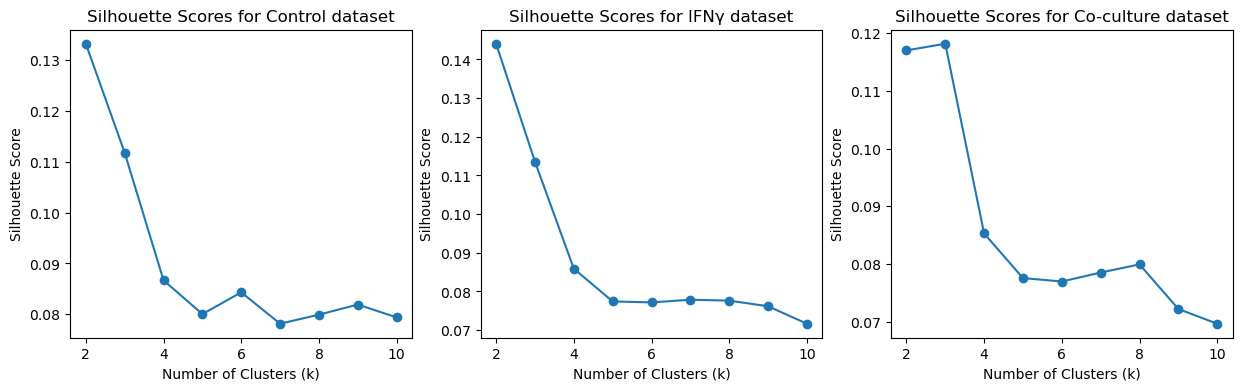

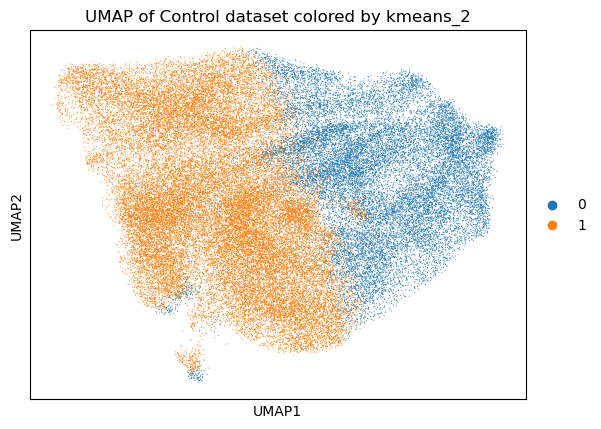

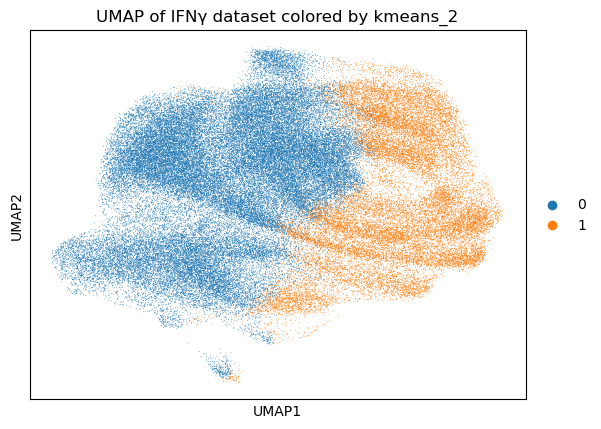

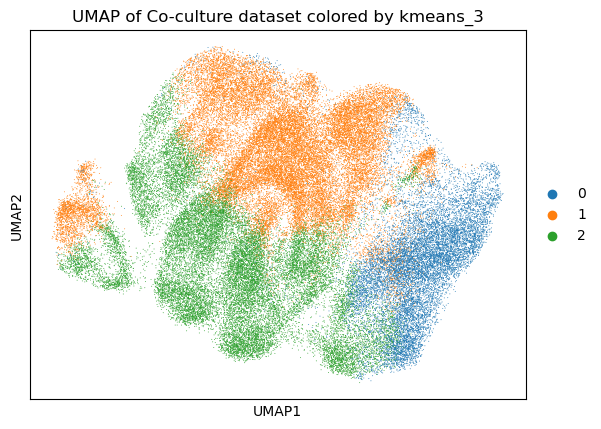

In [ ]:
# compute the silhouette scores for each k value to pick the best k value for each split dataset to color the UMAPs accordingly
import matplotlib.pyplot as plt

# plot all silhouette scores across all k values for each split
fig, axes = plt.subplots(1, 3, figsize = (15, 4))   # create a figure with 1 row and 3 columns of subplots to plot the silhouette scores for each split dataset (fig = whole figure, axes = individual panels) 
for ax, key in zip(axes, rna_filtered_split.keys()):    # iterate over each split dataset and panel to plot the silhouette scores for each k value 
    ks = sorted(kmeans_scores[key]) # return sorted list of keys in the subdictionary of silhouette scores for each split dataset (sorted k values)
    ax.plot(ks, [kmeans_scores[key][k] for k in ks], marker = "o")  # draw a line plot of the silhouette scores for each k value for the current split dataset in the current panel (marker 'o' draws a dot at each data point)
    ax.set_title(f"Silhouette Scores for {key} dataset")
    ax.set_xlabel("Number of Clusters (k)")
    ax.set_ylabel("Silhouette Score")


for key in rna_filtered_split.keys():
    best_k = max(kmeans_scores[key], key = kmeans_scores[key].get)  # find the k value that maximizes the silhouett score for the current split dataset (key = kmeans_scores[key].get -> rank keys by their corresponding value)
    sc.pl.umap(rna_filtered_split[key], color = f"kmeans_{best_k}", title = f"UMAP of {key} dataset colored by kmeans_{best_k}") # plot UMAP colored according to the clusters with the best silhouette score 

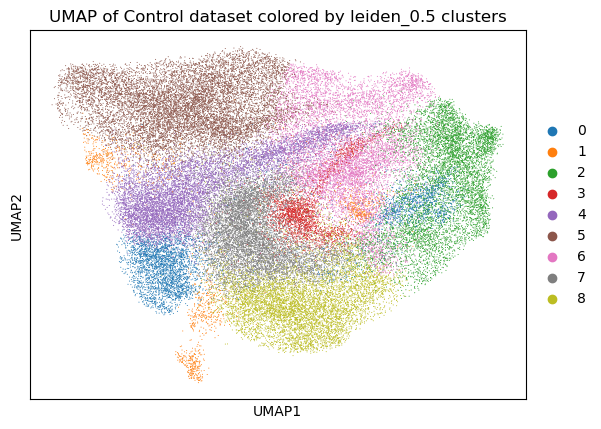

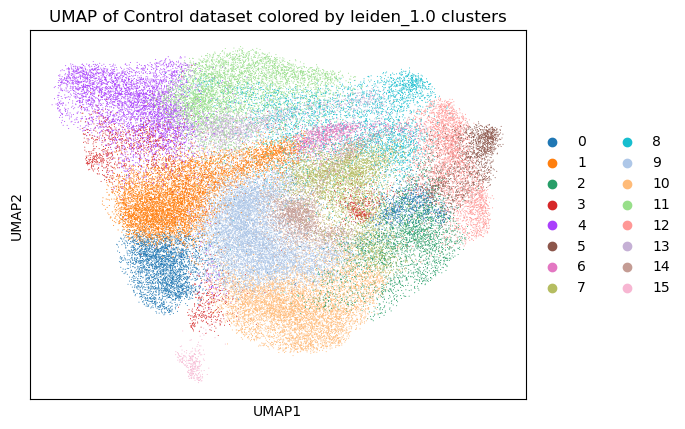

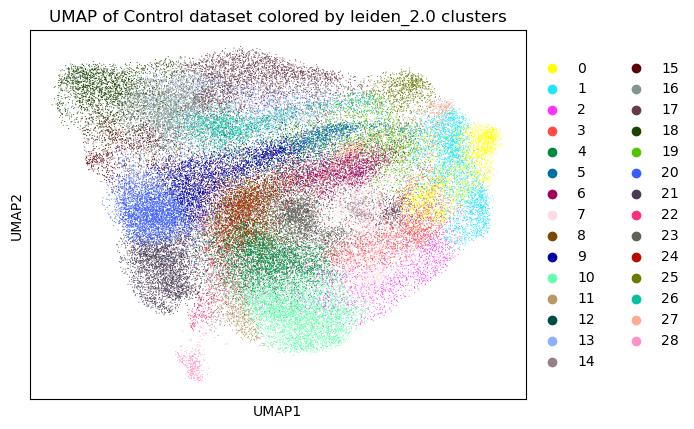

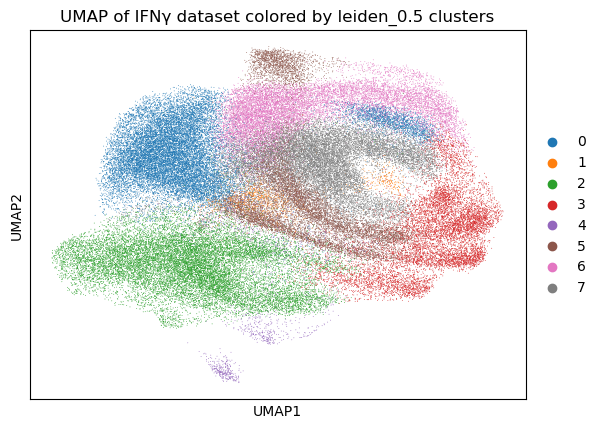

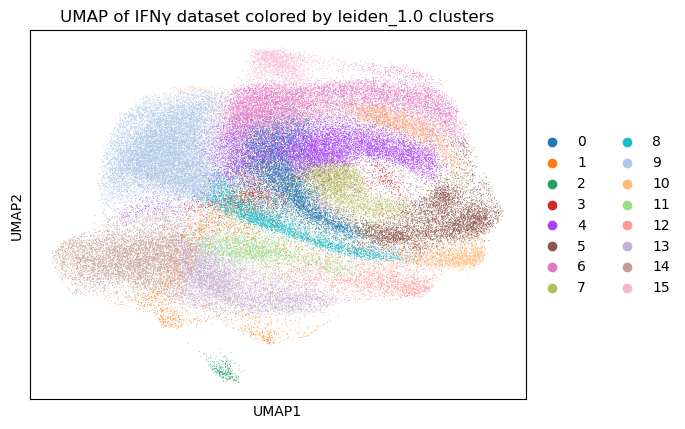

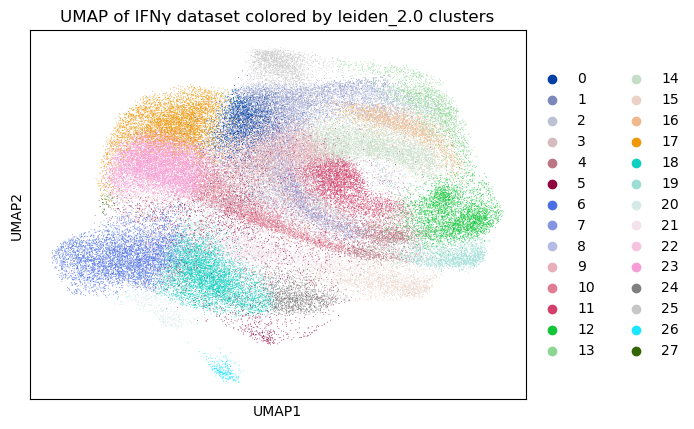

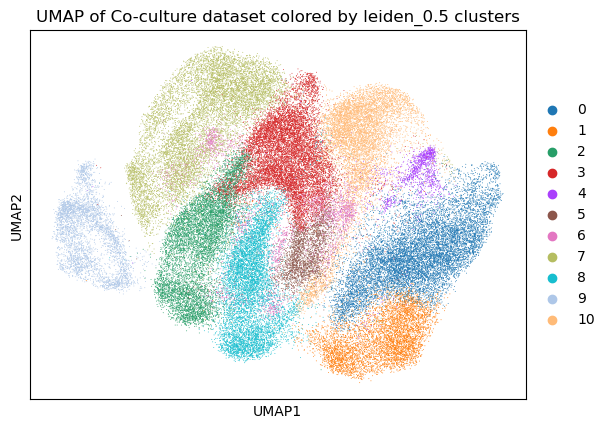

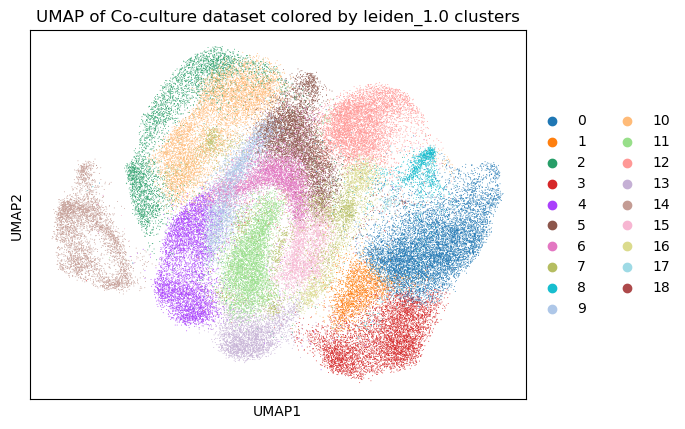

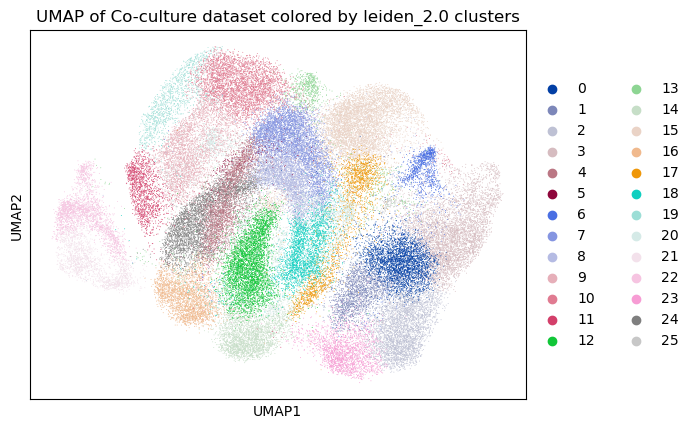

In [ ]:
# plot the umaps again and color by leiden clusters for each split dataset and resolution
for key in rna_filtered_split.keys():
    for res in [0.5, 1.0, 2.0]:
        sc.pl.umap(rna_filtered_split[key], color = f"leiden_{res}", title = f"UMAP of {key} dataset colored by leiden_{res} clusters")

#### Resolution 0.5 seems to be the best choice across all three conditions. At that resolution, the clusters mostly line up with real, visually separated regions of the UMAP rather than arbitrary cuts through a continuous blob of cells. 

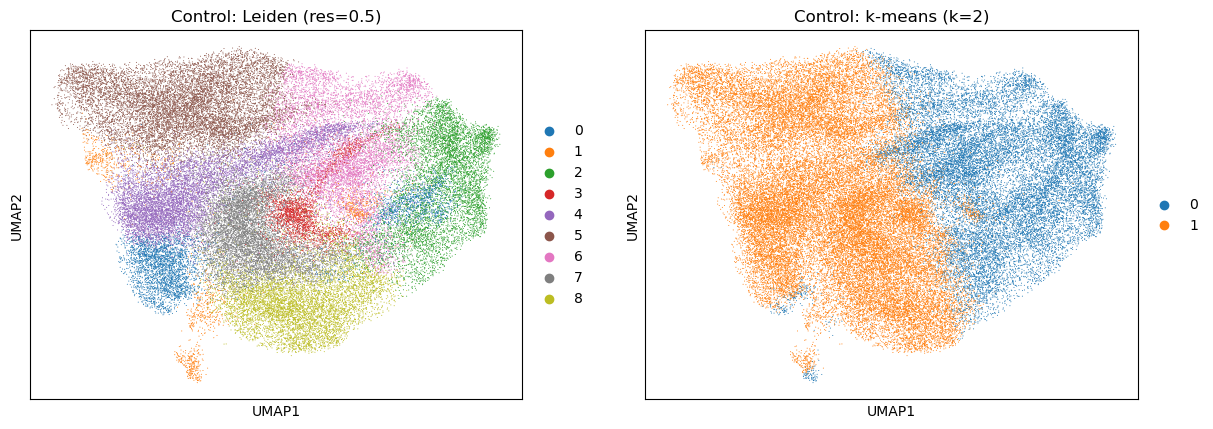

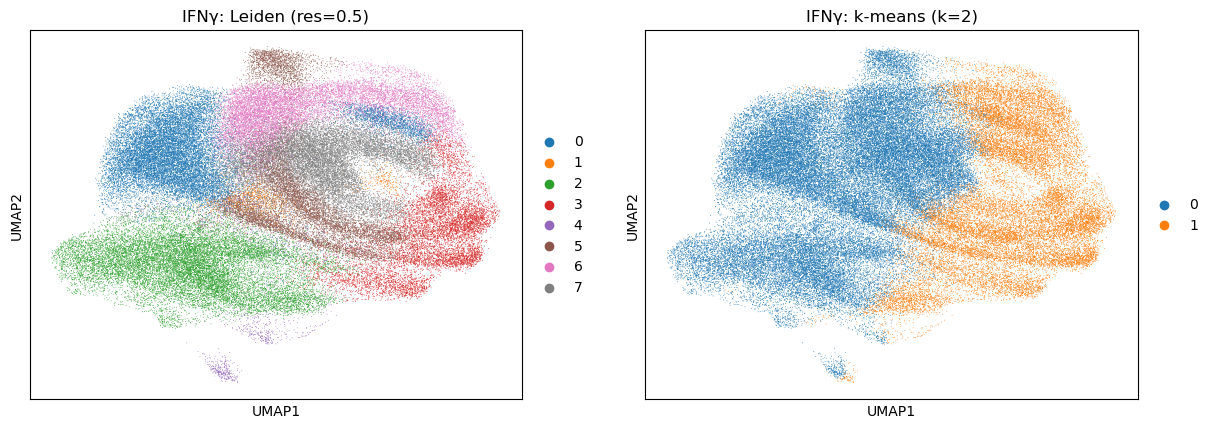

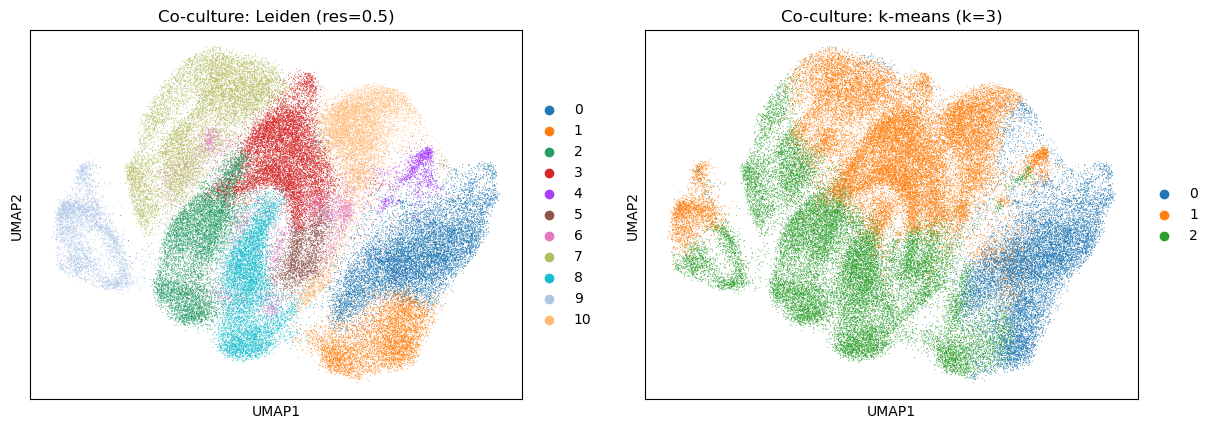

In [ ]:
# plot the umaps again and color by leiden clusters resolution 0.5 and k means clusters for the best k value each 
for key in rna_filtered_split.keys(): # iterate over each split
    best_k = max(kmeans_scores[key], key=kmeans_scores[key].get) # get k with best silhouette score again
    sc.pl.umap(
        rna_filtered_split[key],
        color=["leiden_0.5", f"kmeans_{best_k}"],
        title=[f"{key}: Leiden (res=0.5)", f"{key}: k-means (k={best_k})"] # plot umap for each split twice and color by leiden 0.5 and best kmeans clusters
    )

Now we want to analyze which perturbations behave similarly by analyzing which are found in the same clusters for both clustering methods

In [ ]:
# first store the names of the clustering columns we are using for each method (cluster names) in a dictionary for each split dataset (for leiden the same but different for k values for each split)
cluster_columns = {}
for key in rna_filtered_split.keys(): # iterate over each split
    cluster_columns[key] = {
        "leiden" : "leiden_0.5", # for leiden only 0.5 resolution
        "kmeans" : f"kmeans_{max(kmeans_scores[key], key=kmeans_scores[key].get)}" # for k-means store best k value (silhouette score)
    }

In [ ]:
rna_filtered_split['Control'].obs

,library_preparation_protocol,perturbation_2,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,...,kmeans_4,kmeans_5,kmeans_6,kmeans_7,kmeans_8,kmeans_9,kmeans_10,leiden_0.5,leiden_1.0,leiden_2.0
cell_name,,,,,,,,,,,,,,,,,,,,,
CELL_1,10X 3' v3 sequencing,Control,1,HLA-B_2,10832.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,...,1,2,5,1,6,5,6,0,0,0
CELL_2,10X 3' v3 sequencing,Control,2,nan,10731.0,NGFR_3;SERPINF1_3,NGFR,cell_line_co-culture,True,melanoma,...,3,4,0,6,4,2,2,4,6,5
CELL_3,10X 3' v3 sequencing,Control,1,HLA-B_2,28821.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,...,3,4,0,6,4,2,2,6,7,6
CELL_4,10X 3' v3 sequencing,Control,2,nan,15322.0,NMRK1_3;S100A6_3,NMRK1,cell_line_co-culture,True,melanoma,...,0,0,4,2,1,7,0,8,10,10
CELL_5,10X 3' v3 sequencing,Control,0,nan,10314.0,nan,control,cell_line_co-culture,True,melanoma,...,2,1,3,3,5,6,1,5,3,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL_57623,10X 3' v3 sequencing,Control,1,NO_SITE_229,13723.0,NO_SITE_229,control,cell_line_co-culture,True,melanoma,...,3,3,5,1,5,6,6,5,13,26
CELL_57624,10X 3' v3 sequencing,Control,1,NPC1_2,20148.0,NPC1_2,NPC1,cell_line_co-culture,True,melanoma,...,1,2,2,5,2,3,3,6,8,25
CELL_57625,10X 3' v3 sequencing,Control,2,nan,7352.0,CDK6_1;ONE_NON-GENE_SITE_241,control,cell_line_co-culture,True,melanoma,...,0,3,4,2,7,4,4,8,10,10


In [ ]:
# define a function that computes the top cluster for each perturbation relative
# to the control cells distribution for each split dataset and the different clustering methods (leiden and kmeans)
def perturbation_top_clusters(adata, cluster_col): # input = adata object and names of clustering columns (columns in obs)
    cluster_labels = adata.obs[cluster_col] # cluster_labels stored in obs under name in cluster_col (Leiden_0.5, ...) for each cell
    perturbation = adata.obs["perturbation"] # name of perturbed gene in each cell

    # fraction of each perturbation's cells in each cluster (normalized by total cells with a given perturbation -> sum of column = 1)
    crosstab = pd.crosstab(cluster_labels, perturbation, normalize="columns")

    # baseline: cluster proportions among control-guide cells also normalized for all control cells
    control_cells = perturbation == "control"
    background = cluster_labels[control_cells].value_counts(normalize=True)

    # enrichment relative to baseline, then each perturbation's strongest hit
    enrichment = crosstab.div(background, axis=0) # divide the values for each perturbation in a cluster by the proportion of control cells in that cluster (matched by rows)
    top_cluster = enrichment.idxmax(axis=0) # return cluster in which a respective perturbation is most enriched relative to control cells (for each column = perturbation -> across all rows = clusters)
    return top_cluster # return most enriched clusters' names indexed by perturbation name

In [ ]:
# compute the top cluster for each perturbation relative to the control cells for each split dataset and the different clustering methods
top_clusters = {} # dictionary to store for each split and clustering method the top enriched clusters for each perturbation
for key in rna_filtered_split.keys(): # iterate over each split
    top_clusters[key] = {} # sub dictionary for each condition
    for method, col in cluster_columns[key].items(): # iterate over each clustering method (leiden or kmeans), and the exact resolution/k-value (column in obs)
        top_clusters[key][method] = perturbation_top_clusters(rna_filtered_split[key], col) # store the top clusters for each perturbation for given method and split in the dictionary

# now we have for each perturbation its top cluster

In [ ]:
top_clusters

{'Control': {'leiden': perturbation
  A2M        0
  ACSL3      8
  ACTA2      2
  AEBP1      6
  AGA        3
            ..
  VDAC2      8
  WBP2       0
  WNT7A      3
  XAGE1A     0
  control    0
  Length: 249, dtype: category
  Categories (9, object): ['0', '1', '2', '3', ..., '5', '6', '7', '8'],
  'kmeans': perturbation
  A2M        0
  ACSL3      1
  ACTA2      0
  AEBP1      0
  AGA        1
            ..
  VDAC2      0
  WBP2       0
  WNT7A      0
  XAGE1A     0
  control    0
  Length: 249, dtype: category
  Categories (2, object): ['0', '1']},
 'IFNγ': {'leiden': perturbation
  A2M        7
  ACSL3      0
  ACTA2      1
  AEBP1      7
  AGA        3
            ..
  VDAC2      5
  WBP2       3
  WNT7A      1
  XAGE1A     7
  control    0
  Length: 249, dtype: category
  Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7'],
  'kmeans': perturbation
  A2M        1
  ACSL3      0
  ACTA2      1
  AEBP1      1
  AGA        1
            ..
  VDAC2      1
  WBP2  

In [ ]:
# create a dictionary that stores for each split and clustering method 
# the perturbations which are most enriched in each cluster 
perturbation_groups = {}
for key in rna_filtered_split.keys(): # iterate over each split
    perturbation_groups[key] = {}
    for method in ["leiden", "kmeans"]: # iterate over each method in each split
        labels = top_clusters[key][method] # the cluster labels for each perturbation in a split under leiden/kmeans indexed by perturbation
        perturbation_groups[key][method] = labels.groupby(labels).groups # nested dictionary with an entry for each split, method combination -> value = group labels by its own values (cluster labels) and then return all cluster labels and the perturbations in each cluster

# now for each cluster we have its most enriched perturbations (flipped top_clusters basically)

/tmp/ipykernel_27980/3932075199.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perturbation_groups[key][method] = labels.groupby(labels).groups


In [ ]:
len(perturbation_groups["Control"]["kmeans"]["0"]) + len(perturbation_groups["Control"]["kmeans"]["1"]) == len(rna_filtered.obs["perturbation"].unique())

True

In [ ]:
# Print the perturbations in each cluster for each split and clustering method
for key in rna_filtered_split.keys(): # iterate over splits
    for method in ["leiden", "kmeans"]: # iterate over methods in splits
        print(f"Condition = {key} and Clustering method = {method}:") # print split and method for better structure
        for cluster_id, perturbations in perturbation_groups[key][method].items(): # iterate over all clusters and return both the cluster id and all perturbations in this cluster
            print(f"Cluster {cluster_id} ({len(perturbations)} perturbations): {list(perturbations)}") # print cluster id, number of perturbations in this cluster and all perturbations in this cluster
        print() # add gap 


Condition = Control and Clustering method = leiden:
Cluster 0 (42 perturbations): ['A2M', 'B2M', 'CCR10', 'CD63', 'CDH19', 'CDKN1A', 'CDKN2B', 'CORO1A', 'DNMT1', 'EMP1', 'FGFR1', 'FKBP4', 'GPATCH4', 'GSEC', 'HLA-E', 'HLA-F', 'ISYNA1', 'KLF4', 'LRPAP1', 'LY96', 'MC1R', 'MDH2', 'MYC', 'NT5E', 'PIK3IP1', 'PSMB8-AS1', 'PUF60', 'RNF213', 'RTP4', 'SAT1', 'SDC3', 'SGK1', 'SLC5A3', 'SLC7A5P1', 'SNHG6', 'ST6GALNAC2', 'TIMM50', 'TMED10', 'TXNDC17', 'WBP2', 'XAGE1A', 'control']
Cluster 1 (3 perturbations): ['EIF4A1', 'ROMO1', 'TUBB']
Cluster 2 (46 perturbations): ['ACTA2', 'APOE', 'CD58', 'CD59', 'CD151', 'CITED1', 'CTPS1', 'CTSD', 'CTSO', 'CYP27A1', 'DNAJC9', 'EEA1', 'EIF2S3', 'ENPP1', 'FBL', 'GAA', 'HASPIN', 'HLA-DRB5', 'HLA-H', 'HNRNPC', 'IRF4', 'JAK1', 'JMJD7', 'KDR', 'LRRC75A-AS1', 'MRPL47', 'NMRK1', 'PROS1', 'RAB27A', 'RNASEH2A', 'RRS1', 'RUVBL2', 'SAE1', 'SDCBP', 'SET', 'SNRPF', 'SNRPG', 'SPESP1', 'SPINT1', 'STAT1', 'STAT3', 'TAPBPL', 'TGFB1', 'TM4SF1', 'TRIM22', 'TTLL1']
Cluster 3 (60 per

In [ ]:
# save the perturbation groups as a dataframe 
rows = [] # initiate empty list 
for key in rna_filtered_split.keys():
    for method in ["leiden", "kmeans"]: # iterate over conditions and clustering methods
        for cluster_id, perturbations in perturbation_groups[key][method].items(): # iterate over all clusters for each condition/method pair and return cluster id and list of perturbations
            for pert in perturbations: # iterate over each perturbation in a cluster
                rows.append({
                    "condition": key,
                    "method": method,
                    "cluster": cluster_id,
                    "perturbation": pert,
                }) # append a row for each perturbation tagged with its corresponding cluster, clustering method, and condition

perturbation_groups_df = pd.DataFrame(rows) # build a dataframe from the rows for each perturbation under each condition, method and cluster
perturbation_groups_df.to_csv("/home/ubuntu/data/frangieh/perturbation_groups.csv", index=False) # safe as csv


In [ ]:
# reload the dataframe
import pandas as pd
perturbation_groups_df = pd.read_csv("/home/ubuntu/data/frangieh/perturbation_groups.csv")
#len(perturbation_groups_df) == len(rna_filtered.obs["perturbation"].unique()) * 2 * 3 

In [ ]:
perturbation_groups_df.head()

,condition,method,cluster,perturbation
0,Control,leiden,0,A2M
1,Control,leiden,0,B2M
2,Control,leiden,0,CCR10
3,Control,leiden,0,CD63
4,Control,leiden,0,CDH19


In [ ]:
# define paper modules (which perturbations have similar effects)
paper_modules = {
    # JAK-STAT signaling pathways
    "JAK_STAT": ["STAT1", "JAK1", "JAK2", "IFNGR1", "IFNGR2"],
    # Other modules found in the paper figure 4d page 33 in author manuscript
    "Module_1": ["CD59", "CDH19", "IRF3", "RB1", "SOX4", "SP100"],
    "Module_2": ["CD58", "CTSD", "CXCR4", "HLA-C", "HLA-H", "NUP50-AS", "SMAD4"],
    "Module_3": ["CDK4", "CTSA", "FOS", "HLA-A", "HLA-E"],
    "Module_5": ["EIF3K", "LAMP2", "NPC1", "NPC2", "SEC11C", "FBXO32", "SAT1"],
    "Module_6": ["B2M", "CCR10", "HLA-B", "NGFR", "TGFB1"],
    # Other modules not explicitly named (4, 7, 8)
}

In [ ]:
# compute the purity of modules in computed clusters
def module_match_score(perturbation_groups_df, condition, method, paper_modules): # input = perturbations_df, condition, method and modules froom the paper
    # subset the dataframe to one condition and one clustering method
    subset = perturbation_groups_df[(perturbation_groups_df['condition'] == condition) & (perturbation_groups_df['method'] == method)]
    # set perturbations as index and return cluster column -> clusters labeled by perturbation
    subset_clusters = subset.set_index('perturbation')['cluster']
    # total number of perturbations in each cluster, for this condition/method
    cluster_sizes = subset['cluster'].value_counts()
    # initialize results
    results = {}
    # iterate over the paper modules (name and genes)
    for module_name, genes in paper_modules.items():
        # define genes present as each gene that is found in both the subsetted dataframe and the module (some where dropped in QC)
        genes_present = [g for g in genes if g in subset_clusters.index]
        # define the respective clusters for each gene present
        clusters = subset_clusters.loc[genes_present]
        # return the most abundant cluster (if tied picks the first)
        mode_cluster = clusters.mode()[0]
        # fraction of perturbations in the most frequent cluster
        purity = (clusters == mode_cluster).mean()
        results[module_name] = {
            'purity': purity,
            'n_genes_module': len(genes_present),
            'matched_cluster': mode_cluster,
            'matched_cluster_size': cluster_sizes[mode_cluster],
            'assignments': clusters.to_dict(),
        }
    return results


In [ ]:
# similarly to the perturbations dataframe store each purity score for each module under each condition and method in a separate row together with the n_genes in this module, cluster id of matched cluster with the cluster and cluster size
all_results = []
for condition in perturbation_groups_df['condition'].unique():
    for method in perturbation_groups_df['method'].unique(): # iterate over conditions and methods in the perturbations dataframe
        scores = module_match_score(perturbation_groups_df, condition, method, paper_modules) # apply defined function
        for module_name, res in scores.items(): # iterate over all modules and its results under each condition method pair
            all_results.append({
                "condition": condition,
                "method": method,
                "module": module_name,
                "purity": res["purity"],
                "n_genes": res["n_genes_module"],
                "matched_cluster": res['matched_cluster'],
                "matched_cluster_size": res["matched_cluster_size"],
            }) # append a row for each condition and method pair tagged with condition, method, name of module and teh results of the function

purity_modules_df = pd.DataFrame(all_results) # create dataframe 
purity_modules_df


,condition,method,module,purity,n_genes,matched_cluster,matched_cluster_size
0,Control,leiden,JAK_STAT,0.400000,5,2,46
1,Control,leiden,Module_1,0.333333,6,3,60
2,Control,leiden,Module_2,0.500000,6,2,46
3,Control,leiden,Module_3,0.400000,5,4,15
4,Control,leiden,Module_5,0.428571,7,3,60
5,Control,leiden,Module_6,0.400000,5,0,42
6,Control,kmeans,JAK_STAT,1.000000,5,0,189
7,Control,kmeans,Module_1,1.000000,6,0,189
8,Control,kmeans,Module_2,0.833333,6,0,189
9,Control,kmeans,Module_3,0.600000,5,0,189


## Discussion 
### Which clustering best captured the biological effects
Comparing UMAP vizualisations across the different clustering methods and resolutions we used, showed that Leiden clustering captured the structure of the data much better than K-means. At resolution 0.5, Leiden clusters seemed to align best with the visually separated regions of the UMAP across all three conditions. At higher resolition the clustering fragmented the clusters further which resulted in the separation of visually coherent areas. K-means clustering selected by silhouette scoring k-values from 2-10 resulted in very coarse clusters (k = 2 for Control and IFN $\gamma$ and k = 3 for Co-culture). Based on this, Leiden clustering at resolution 0.5 was chosen as the primary clustering approach for downstream analysis. 

### Which genetic perturbations show similar effects? 

To identify which perturbations produce similar transcriptional effects, each perturbation was assignet to its most-enriched cluster (relative to the cluster distribution of control cells). This way, perturbations were grouped suggesting a similar effect on the cells transcriptional state. Several of these groupings correspond to functionally coherent gene sets such as the sequential components of the JAK/STAT signalliung pathway (STAT1/JAK1/JAK2/IFNGR1/IFNGR2) in co-culture and under IFN $\gamma$ treatment, joined by MHC class 1 genes HLA-A and HLA-C in co-cultured cells and HLA-B and HLA-C in IFN-$\gamma$ treated cells indicating an interferon/immune-context dependent activation. Others include B2M and HLA-B in the co-cultured condition which form a separate cluster possibly because B2M is a structural component of the MHC-1 complex and not a signalling intermediate. Another cluster contained immune checkpoint- and adhesion-related genes CD47, CD274, CDH19, TMEM173, whilst a smaller cluster grouped CCND1 and MYC which is consistent with their proliferative role. Also lysosomal genes such as NPC2, PSAP, and TPP1 were grouped across all three conditions, similarly to CD274 (immune checkpoint ligand), and TAPBP (loading peptides onto MHC class 1) which are involved in the immunogenic visibility of tumore cells. Together these results show that perturbations have similar effects on the transcriptional state especially when they are involved in similar processes or even the same signaling pathway. 

### How well does this approach align with the findings of the paper? 
To assess how well this unsupervised clustering approach captured the finding described in the paper, gene modules reported in Fig 4c/d were compared against the computed clusters using a purity score. This purity score is the fraction of a module's genes sharing the same, most common cluster. This purity is then reported alongside the cluster size and the module size for more context. Once again the JAK/STAT module showed the stronges agreement with the clusters under IFN $\gamma$ and co-culture condition where all five genes fell into the same cluster (purity = 1.0, cluster size = 63 and 26). Under control they only showed a purity of 40% which is consistent as there is no interferon signaling there and the pathway does not react anyways. The remaining modules were revovered far more weakly under Leiden, plausibly reflecting that these modules combine functionally more heterogeneous genes with smaller or more widely distributed transcriptional effects than the dominant JAK/STAT signaling especially under the analyzed conditions. However, when comparing to the baseline purity which should be equal to $1/n_{clusters}$ (1/n * module size / module size = 1/n)(0.091-0.125 for leiden) by random assignment, the observed purities are still elevated by factor 3-5. K-means showed a different pattern here with higher purity scores most of the time but its matched clusters were also consistently much larger (up to 84% of all perturbations) thus a much higher purity is almost guaranteed regardless of shared bilogical effects (0.333-0.500 at random). Together the leiden clustering at 0.5 resolution recovers the most prominent finding of the paper, while more subtle, secondary mechanisms described are only weakly captured in this approach. 

### Limitations and directions for further analysis
The analysis above already provides consistent, quantitative support for the groupings discussed, and a few extensions could add further depth. Leiden's resolution was selected via visual alignment with the UMAP structure; computing an analogous quantitative score (as was done via silhouette scoring for k-means) would allow for an even more direct comparison between the two methods. The purity scores were benchmarked against an analytic $1/n_{clusters}$ random baseline, a simple and effective first approximation; a permutation-based null model (repeatedly shuffling perturbation-to-cluster labels) would offer a complementary, fully empirical significance estimate. Assigning each perturbation to a single most-enriched cluster captures its dominant transcriptional effect well, but examining secondary cluster enrichment and cell-to-cell heterogeneity within a perturbation could add further nuance in future work.
